## Customer Segmentation Analysis

In this section, customers are grouped into distinct segments using KMeans clustering based on revenue, service usage, and engagement-related features.

### Objective
The goal is to identify meaningful customer groups that can support:
- targeted retention strategies
- personalized marketing
- upselling opportunities
- churn risk management

### Clustering Features
The segmentation is based on:
- Monthly Charges
- Total Charges
- service_count
- engagement_score
- avg_monthly_value

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("engineered_data.csv")

Monthly Charges: current customer value

Total Charges: lifetime value

service_count: product adoption breadth

engagement_score: involvement/usage intensity

avg_monthly_value: spending behavior over time

In [2]:
features = [
    "Monthly Charges",
    "Total Charges",
    "service_count",
    "engagement_score",
    "avg_monthly_value",
]

X = df[features]

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

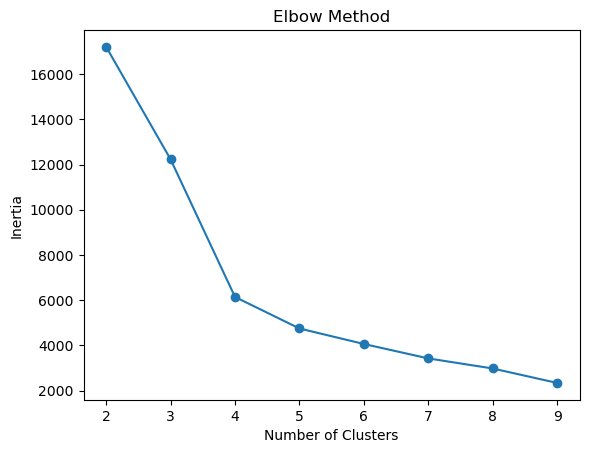

In [4]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### Choosing the Number of Clusters
The elbow method was used to compare inertia across different values of K.  
The curve begins to flatten around **K = 4**, suggesting that 4 clusters provide a good balance between model simplicity and meaningful segmentation.

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [6]:
cluster_profile = df.groupby("cluster")[features].mean().round(2)
cluster_profile

,Monthly Charges,Total Charges,service_count,engagement_score,avg_monthly_value
cluster,,,,,
0,77.17,1421.60,1.0,21.77,67.40
1,27.52,584.53,1.0,13.63,22.69
2,95.60,5543.93,1.0,37.06,93.95
3,42.02,1502.61,0.0,17.97,38.45


In [7]:
df["cluster"].value_counts().sort_index()

cluster
0    2522
1    1927
2    1862
3     679
Name: count, dtype: int64

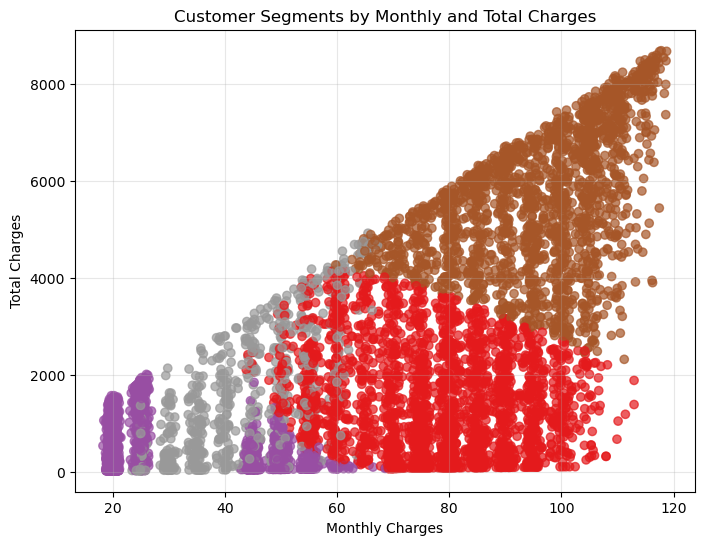

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["Monthly Charges"],
    df["Total Charges"],
    c=df["cluster"],
    cmap="Set1",
    alpha=0.7
)
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Customer Segments by Monthly and Total Charges")
plt.grid(alpha=0.3)
plt.show()

In [9]:
cluster_names = {
    0: "High Value Loyal",
    1: "Low Value New",
    2: "At Risk Customers",
    3: "Premium Customers"
}

df["segment"] = df["cluster"].map(cluster_names)

In [10]:
segment_summary = df.groupby("segment")[features].mean().round(2)
segment_summary

,Monthly Charges,Total Charges,service_count,engagement_score,avg_monthly_value
segment,,,,,
At Risk Customers,95.60,5543.93,1.0,37.06,93.95
High Value Loyal,77.17,1421.60,1.0,21.77,67.40
Low Value New,27.52,584.53,1.0,13.63,22.69
Premium Customers,42.02,1502.61,0.0,17.97,38.45


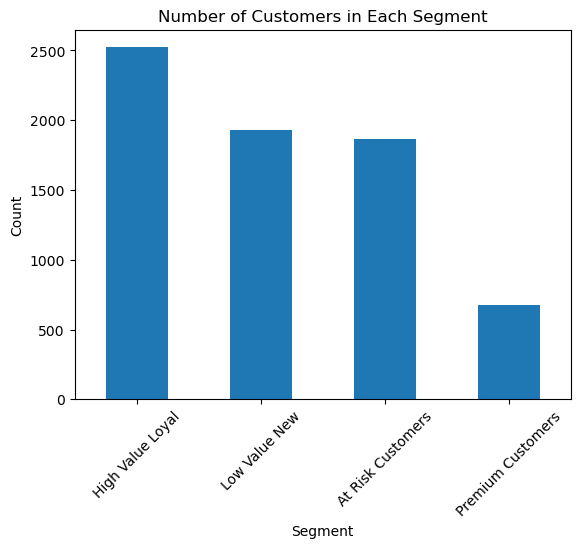

In [11]:
df["segment"].value_counts().plot(kind="bar")
plt.title("Number of Customers in Each Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [12]:
df.to_csv("segmented_data.csv", index=False)

## Customer Segmentation Insights

Customers were grouped into 4 segments using KMeans clustering.

### Segment 1: High Value Loyal Customers
- High total charges
- High engagement
- Long tenure
- Important to retain

### Segment 2: Low Value New Customers
- Low tenure
- Low spending
- Growth potential

### Segment 3: At Risk Customers
- Moderate spending
- Lower engagement
- Likely to churn

### Segment 4: Premium Customers
- High monthly charges
- High service usage
- High revenue contribution

This segmentation enables targeted business strategies for different customer groups.

## Final Business Insight

This segmentation reveals that customer value is strongly driven by both spending level and tenure.

The presence of a large group of new high-spending customers highlights a critical opportunity: early retention efforts can significantly increase long-term revenue.

By converting high-potential customers into loyal ones, the business can maximize customer lifetime value while reducing future churn risk.

This segmentation provides a strong foundation for targeted marketing, retention strategies, and revenue optimization.

## Business Recommendations

- Focus retention campaigns on New High-Potential customers to maximize lifetime value.
- Reward High Value Loyal customers with loyalty programs and premium support.
- Develop targeted offers to move Mid-Value customers into higher segments.
- Use cost-efficient strategies for At Risk customers, such as automated engagement campaigns.